(lecture05:homework)=
# Homework 5

+ Type your name and email in the "Student details" section below.
+ Develop the code and generate the figures you need to solve the problems using this notebook.
+ For the answers that require a mathematical proof or derivation you can either:
    
    - Type the answer using the built-in latex capabilities. In this case, simply export the notebook as a pdf and upload it on gradescope; or
    - You can print the notebook (after you are done with all the code), write your answers by hand, scan, turn your response to a single pdf, and upload on gradescope.

+ The total homework points are 100. Please note that the problems are not weighed equally.

```{note}
+ Please match all the pages corresponding to each of the questions when you submit on gradescope.
```

## Student details

+ **First Name:** Timothy
+ **Last Name:** Lee
+ **Email:** lee5695@purdue.edu

Again, let me set you up with some code for plotting:

In [14]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(rc={"figure.dpi":100, 'savefig.dpi':300})
sns.set_context('notebook')
sns.set_style("ticks")
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina', 'svg')

/tmp/ipython-input-367591302.py:8: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina', 'svg')


## Problem 1 - Analysis of experimental srtess-strain curves of alluminum 6061-T651

You are going to analyze the dataset collected by {cite}`AAKASH2019104085`.
They perform two types of experiments.
We are going to focus on the "uniaxial tension experiment."
This is what it is all about:
+ They took several speciments of alluminum 6061-T651 ([a high-temperature alluminum alloy](https://en.wikipedia.org/wiki/6061_aluminium_alloy)).
+ The shape of these speciments is like this:

```{figure} https://ars.els-cdn.com/content/image/1-s2.0-S2352340919304391-gr1_lrg.jpg
---
height: 300px
name: directive-fig
---
Geometry of the uniaxial tension specimen.
```
+ They mounted the speciment (using the holes you see on the sides) on a machine that applies tension:

```{figure} https://ars.els-cdn.com/content/image/1-s2.0-S2352340919304391-gr5_lrg.jpg
---
height: 300px
name: directive-fig2
---
The mounted specimen.
```
+ They controlled the temperature of the specimen.
+ They applied tension gradually until the speciment broke, recorging at each step the strain (% change in length) and the stress (force per cross section area in MPa - megaPascal).

I suggest that you skim through the paper if you want to understand more about the details of the experiment.
Measuring the strains and stresses is not as straightforward as it sounds...

Our goal is to download the data, and for a fixed temperature, create a model for the stress-strain relation.
We are going to do some of the low level stuff.
But, I am going to guide you through this.

+ First, download the complete zipped data from [here](https://data.mendeley.com/datasets/rd6jm9tyb6/2) and unzip it in the directory of your Jupyter notebook.
You have two options. Either do it mannually as we did in {ref}`lecture03:homework` or run the code segment below to do it from this Jupyter notebook:

In [6]:
# follow redirects (-L), use server's filename (-J), and write to that name (-O)
!curl -L -J -O 'https://data.mendeley.com/public-files/datasets/rd6jm9tyb6/files/559cd828-c044-418a-837c-35ce161c02ab/file_downloaded'

# sanity check: is it actually a zip?
!ls -lh
!file ./*

# unzip whatever came down (often there’s exactly one .zip)
!unzip -o *.zip

# if there are nested zips, expand them too
!unzip -o "*.zip"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   134  100   134    0     0    126      0  0:00:01  0:00:01 --:--:--   126
100 2230k  100 2230k    0     0   855k      0  0:00:02  0:00:02 --:--:-- 1977k
total 2.2M
drwxr-xr-x 1 root root 4.0K Jan 16 14:24 sample_data
-rw-r--r-- 1 root root 2.2M Feb 20 21:58 stress-strain-curves-of-aluminum-6061-t651-from-9-lots-at-6-temperatures-under-uniaxial-and-plain-strain-tension.zip
./sample_data:                                                                                                          directory
./stress-strain-curves-of-aluminum-6061-t651-from-9-lots-at-6-temperatures-under-uniaxial-and-plain-strain-tension.zip: Zip archive data, at least v2.0 to extract, compression method=deflate
Archive:  stress-strain-curves-of-aluminum-6061-t651-from-9-lots-at-6-temperatures-under-uniaxial-and-plain-strain-tension.zip
  inflating: P

+ Now read the data description [here](https://data.mendeley.com/datasets/rd6jm9tyb6/2) very carefully and find a filename that contains data from a uniaxial tension test of 200 degrees C. There multiple files that fit this description. Just pick one of them.

In [7]:
filename = 'T_200_B_2_098_075_12.csv'
print('The file I picked is: ', filename)

The file I picked is:  T_200_B_2_098_075_12.csv


*   Load the file in a dataframe and print it.



In [93]:
import pandas as pd

df = pd.read_csv(filename)
print(df)

       Strain  Stress_MPa
0    0.000063   -0.150531
1    0.000050   -0.006252
2    0.000036    0.324889
3    0.000025    0.796388
4    0.000021    1.472735
..        ...         ...
705  0.162118   99.213185
706  0.162317   98.469072
707  0.162537   97.668598
708  0.162758   96.849801
709  0.162759    0.000000

[710 rows x 2 columns]


+ Plot the stress as a function of the strain. Please label your axes properly.

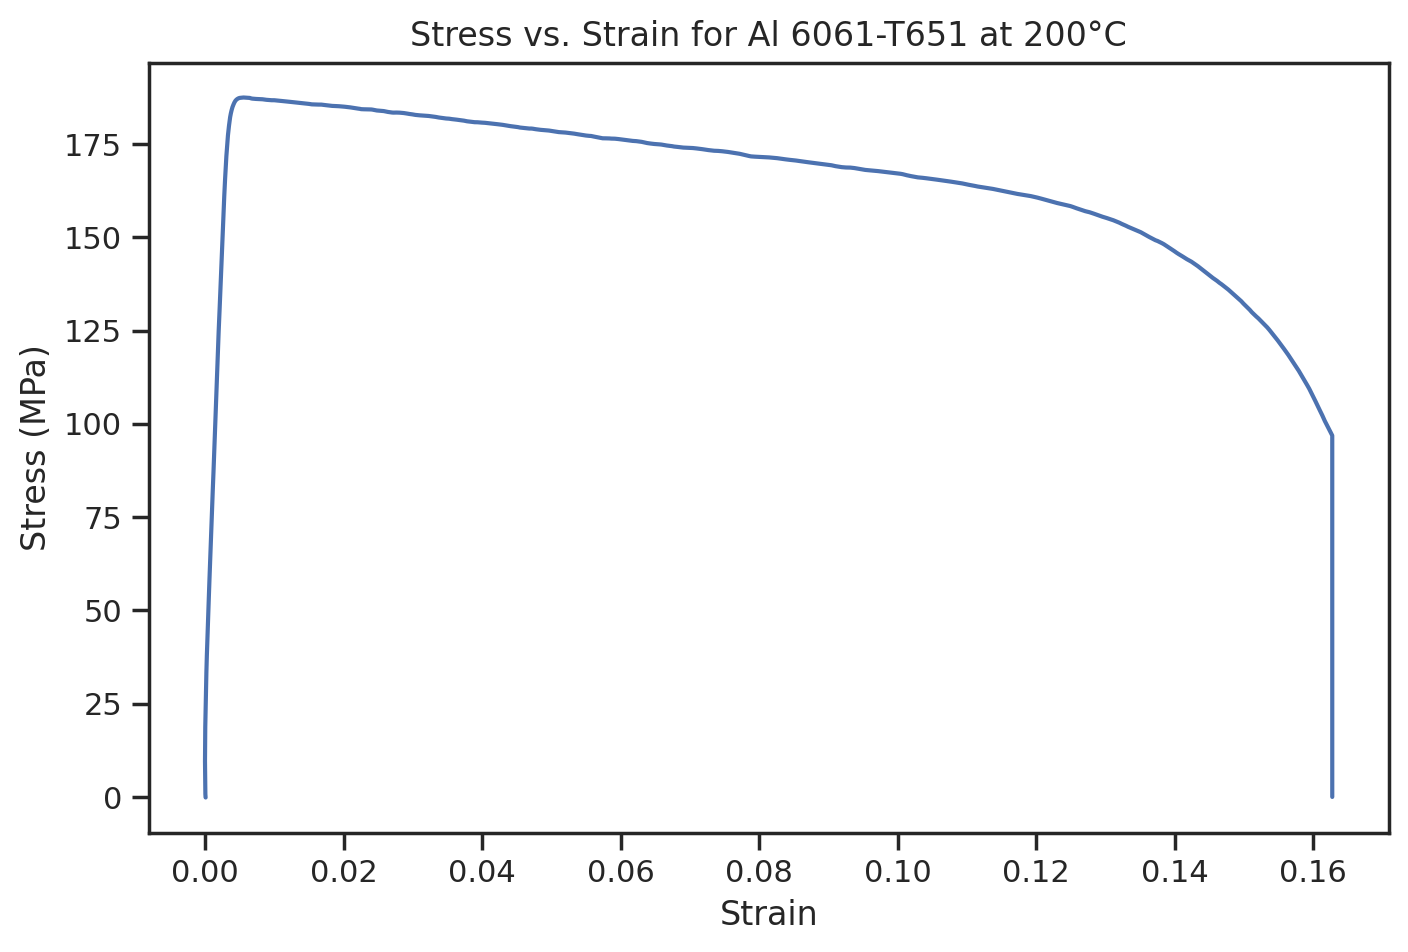

In [21]:
plt.figure(figsize = (8,5))
plt.plot(df['Strain'], df['Stress_MPa'])
plt.xlabel('Strain')
plt.ylabel('Stress (MPa)')
plt.title('Stress vs. Strain for Al 6061-T651 at 200°C')
plt.show();

+ The [ultimate tensile strength](https://en.wikipedia.org/wiki/Ultimate_tensile_strength) (or just "the strength") of a material is the maximum stress that develops under tension before the material breaks. What is the strength of this alluminum alloy? Please, provide your answer below using the `print()` function with a precision of 2 decimal points. How does your answer compare with the strength range for allumunum alloys reported in [wikipedia](https://en.wikipedia.org/wiki/6061_aluminium_alloy)?

In [30]:
stress = df['Stress_MPa']
uts = stress.max()
print(f'The ultimate tensile strength is {uts:.2f} MPa.')
print('\nThe strength range for aluminum alloys, according to Wikipedia, ranges from 124 to 290 MPa.\nHowever, these measurements were taken at room temperature, while the study was conducted at 200\u00b0C.')
print('Therefore, it makes sense that the study\'s ultimate tensile strength is lower.')


The ultimate tensile strength is 187.45 MPa.

The strength range for aluminum alloys, according to Wikipedia, ranges from 124 to 290 MPa.
However, these measurements were taken at room temperature, while the study was conducted at 200°C.
Therefore, it makes sense that the study's ultimate tensile strength is lower.


+ Let's zoom in to low strains. Plot the first 200 observations points of the stress-strain curve.

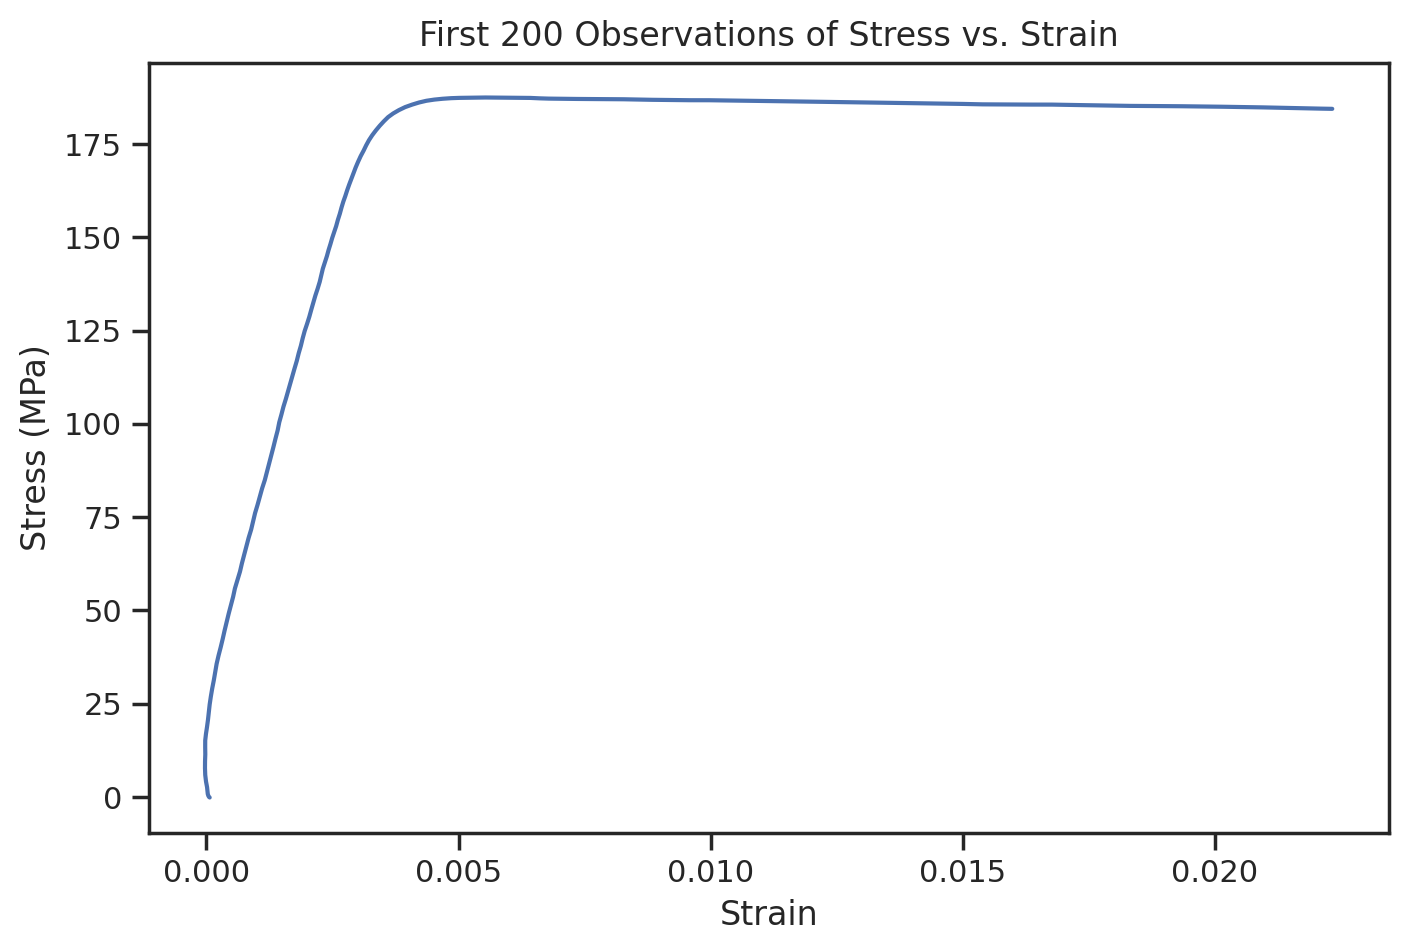

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(df['Strain'][:200], df['Stress_MPa'][:200])
plt.xlabel('Strain')
plt.ylabel('Stress (MPa)')
plt.title('First 200 Observations of Stress vs. Strain')
plt.show();

+ Observe that the experimental data are behaving strangely at very small strains. As a matter of fact, we are getting a few negative strains at the beginning.
Let's throw these observartions away. Start by finding the index $i$ for which `df['Strain'][i]` becomes positive for the first time. You can do this by a visual inspection of `df['Strain'][:30]`.

In [33]:
print(df['Strain'][:30])

0     0.000063
1     0.000050
2     0.000036
3     0.000025
4     0.000021
5     0.000011
6    -0.000010
7    -0.000025
8    -0.000030
9    -0.000029
10   -0.000024
11   -0.000026
12   -0.000025
13   -0.000011
14    0.000010
15    0.000029
16    0.000046
17    0.000063
18    0.000086
19    0.000113
20    0.000145
21    0.000173
22    0.000201
23    0.000239
24    0.000282
25    0.000322
26    0.000359
27    0.000400
28    0.000440
29    0.000484
Name: Strain, dtype: float64


+ Make a new dataframe, call it `clean_df` where you have thrown away the initial data. Then plot the first 200 observations of `clean_df`.

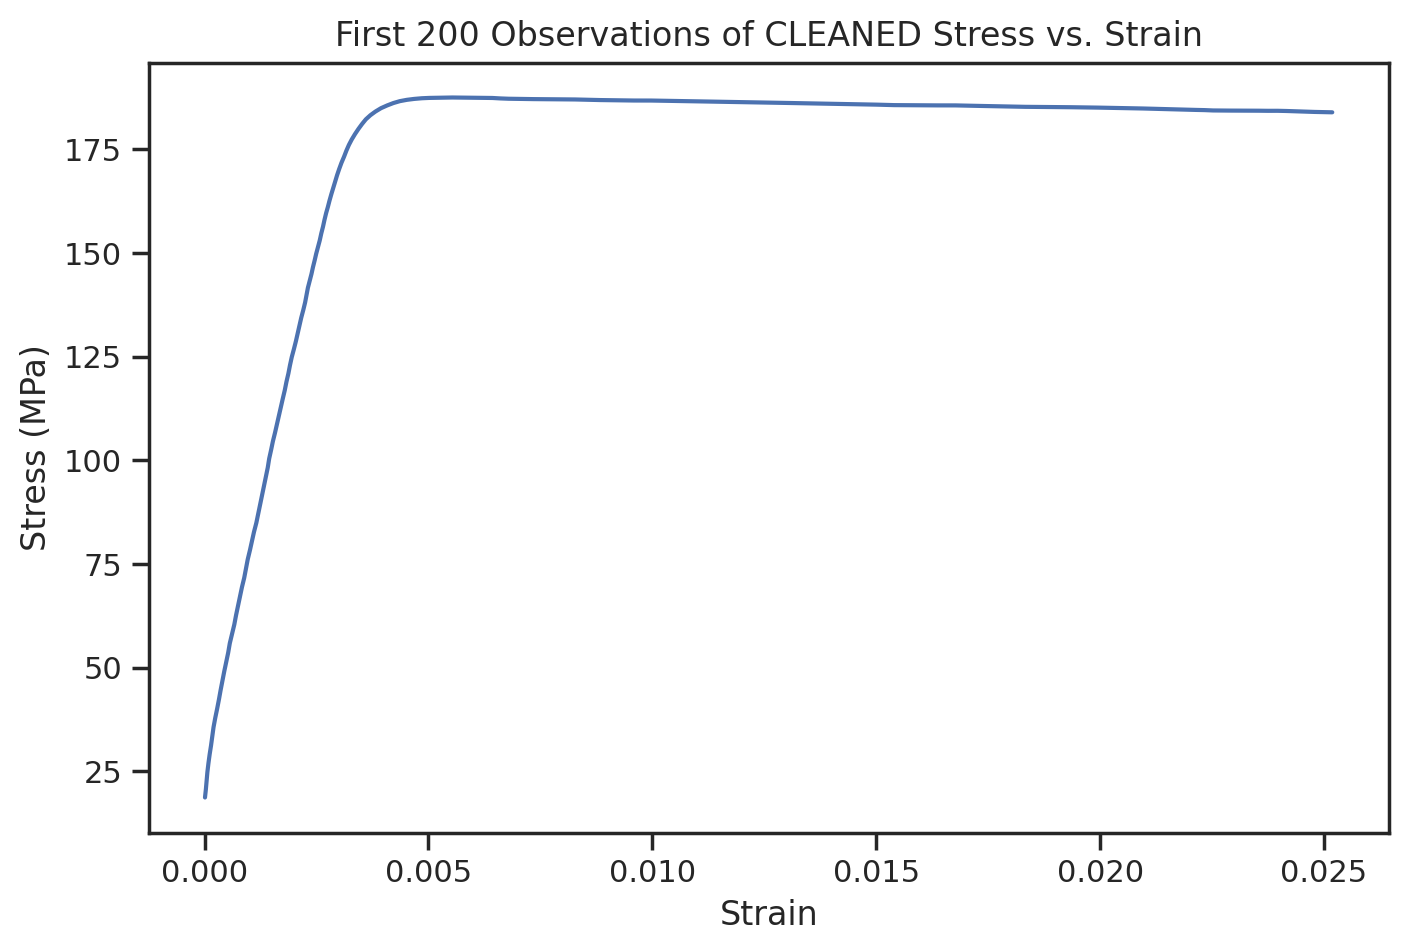

In [45]:
i = 14
clean_df = df[i:].copy()
clean_df = clean_df.reset_index(drop = True)
plt.figure(figsize=(8, 5))
plt.plot(clean_df['Strain'][:200], clean_df['Stress_MPa'][:200])
plt.xlabel('Strain')
plt.ylabel('Stress (MPa)')
plt.title('First 200 Observations of CLEANED Stress vs. Strain')
plt.show();

+ Observe that initially the stress-strain relation is linear. This is the so-called *elastic regime*.
If you deform the material within this regime, it will return to its undeformed state without any permanent deformation effects.
If you deform the material beyond the elastic regime, then you start having what we call *plasticity*.
We are now going to focus exclusively on the linear regime.
Find an index $j$ so that `clean_df[:j]` is fully within the linear regime.
Make a new dataframe, say `linear_df` containing only these data.
You should probably pick $j$ by visual inspection.
And it is not important to pick the maximum $j$ with this property.
Just find one.

In [60]:
j = 75
linear_df = clean_df[:j].copy()
linear_df = linear_df.reset_index(drop = True)

+ In the elastic regime, the stress $\sigma$ is a linear function of the strain $\epsilon$:

$$
\sigma = E\epsilon.
$$

The constant $E$ is called Young's modulus and it has units of GPa (GigaPascal).
Make a function `sigma(epsilon, E)` that calculates the stress given the strain for any Young's modulus. Properly document the docstring of your function.

In [61]:
def sigma(epsilon, E):
    """A linear equation that gives the stress of a material as a function of its strain, within the elastic regime.
    The mathematical equation is:

        stress = E * epsilon

    Arguments:
    epsilon    -   Strain
    E          -   Young's Modulus in GPa

    Returns: The predicted stress in MPa
    """
    stress = epsilon * E * 1000 # 1000 MPa / GPa conversion
    return stress

In [94]:
# Try your function here:
sigma(linear_df['Strain'], 68)

,Strain
0,0.658852
1,1.995436
2,3.138717
3,4.276109
4,5.873166
...,...
70,187.230298
71,189.736455
72,192.537900
73,195.420869


+ If you pay close attention to the data in `linear_df` they do not cross zero.
This is due to a systematic bias in the experiment.
However, this bias is not important for calibrating Young's modulus $E$.
Only the slope of the curve is important for finding $E$.
So, let's make yet another dataframe (I promise you this is the last one) called `clean_linear_df` which removes this systematic bias.
The dataframe `clean_linear_df` should contain the same data as `linear_df` but
    + The strains should all be shifted by the minimum strain in `linear_df`. In other words, subtract from the strains in `clean_linear_df` the smallest strain in `linear_df`, i.e., subtract `linear_df['Strain'].min()`.
    + The stresses should all be shifted by the minimum stress in `linear_df`.

In [71]:
clean_linear_df = linear_df.copy()
clean_linear_df['Strain'] = clean_linear_df['Strain'] - linear_df['Strain'].min()
clean_linear_df['Stress_MPa'] = clean_linear_df['Stress_MPa'] - linear_df['Stress_MPa'].min()

+ Use visual inspection to find a value for the Young's modulus that matches the data in `clean_linear_df`.
Hints: Remember that the stress $\sigma$ is in MPa so you will have to change the units correctly if you $E$ is expressed in GPa.

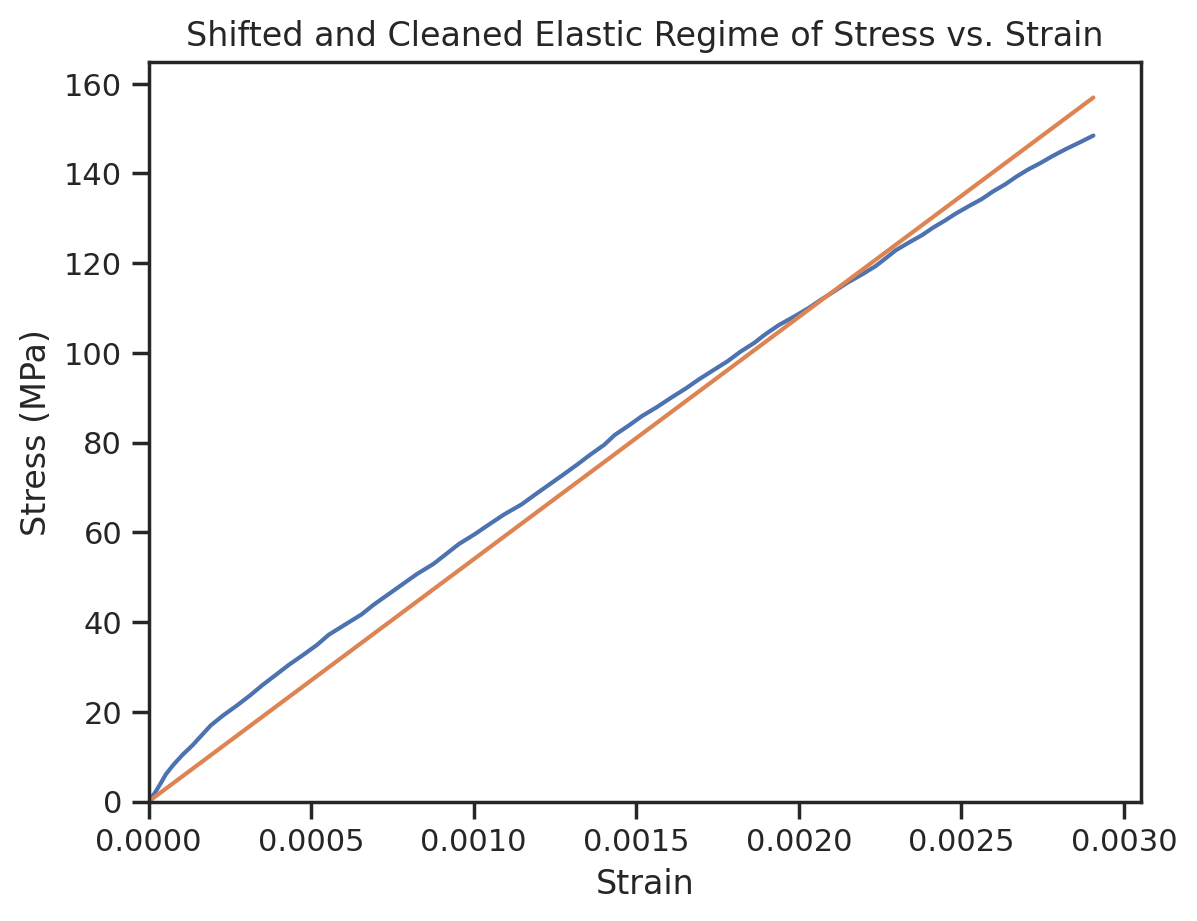

In [91]:
E_estimate = 54

plt.plot(clean_linear_df['Strain'], clean_linear_df['Stress_MPa'])
plt.plot(clean_linear_df['Strain'], sigma(clean_linear_df['Strain'], E_estimate))
plt.xlabel('Strain')
plt.ylabel('Stress (MPa)')
plt.title('Shifted and Cleaned Elastic Regime of Stress vs. Strain')
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.show();

# I estimate a value of 54 GPa for the Young's modulus, as this appears to minimize the total distance between the yellow estimate curve, and the blue actual data curve.

+ How does what you found compare to the [wikipedia](https://en.wikipedia.org/wiki/6061_aluminium_alloy) reported Young's modulus for this material? Why do you think yours is lower/higher? You may want to repeat the analysis above for another experiment with lower temperature (say at room temperature).

Wikipedia states that Aluminum 6061 T6 has a Young's modulus of 68 GPa, which is greater than the Young's modulus that I estimated at 54 GPa. My Young's modulus is lower, meaning that it experiences less stress as strain increases. This makes sense because metals typically become less stiff and easier to work with as they heat up, meaning that they experience less stress per strain.

Run the following code to convert the notebook to a pdf. Verify that the file path to the notebook is correct.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!apt-get install inkscape texlive texlive-xetex texlive-latex-extra pandoc --quiet
!pip install pypandoc --quiet
!jupyter nbconvert --to PDF '/content/drive/MyDrive/Colab Notebooks/Copy of homework_05.ipynb'